#  Install Required Packages

In [1]:
# Run this cell first if packages are not already installed

!pip install optuna
!pip install shap
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install joblib

print("✓ All packages installed successfully!")


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------------ --------------- 1.3/2.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 7.5 MB/s  0:00:00

   ----------- ---------------------------- 2/7 [greenlet]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------------- ----------- 5/7 [alembic]
   ---------------------------------- ----- 6/7 [optuna]
   ---------------------------------- ----- 6/7 [optuna]
   ---------------------------------- ----- 6/7 [optuna]
   ---------------------------------------- 7/7 [optuna]

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:-

# Import Libraries

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Advanced optimization
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Explainable AI
import shap

# Model persistence
import joblib

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 70)
print("ADVANCED CWR PREDICTION MODEL - TIER 1 METHODS")
print("ML-Based Predictive Irrigation System for Paddy Cultivation")
print("=" * 70)
print("\n✓ All libraries imported successfully!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


ADVANCED CWR PREDICTION MODEL - TIER 1 METHODS
ML-Based Predictive Irrigation System for Paddy Cultivation

✓ All libraries imported successfully!
Timestamp: 2026-02-11 18:37:12


# Load Dataset

✓ Dataset loaded successfully: paddy_CWR_dataset_20260211_163930.csv

Dataset shape: (1000, 7)
Features: 6
Samples: 1000

First 5 samples:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
0,6.01,95.1,75.7,8.70,4.47,3,25.46
1,7.36,99.8,96.6,9.40,1.84,4,30.98
2,8.61,91.8,50.3,9.01,1.13,4,14.44
3,5.59,92.0,52.7,6.59,0.00,4,38.81
4,0.31,52.2,83.4,5.28,0.00,3,45.00



Dataset Statistics:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.216390,85.257900,57.32530,6.822410,3.162580,3.000000,17.304340
std,3.624824,14.909519,24.79229,1.744492,4.711283,1.414921,16.910791
min,0.000000,45.300000,15.10000,4.020000,0.000000,1.000000,0.000000
25%,0.117500,75.300000,36.00000,5.490000,0.000000,2.000000,0.000000
50%,4.425000,92.350000,57.30000,6.285000,0.050000,3.000000,12.280000
75%,7.100000,96.400000,78.12500,8.760000,5.007500,4.000000,30.680000
max,11.850000,100.000000,100.00000,10.000000,19.630000,5.000000,45.000000



✓ No missing values detected

CWR Distribution:
  Min:    0.00 mm
  Max:    45.00 mm
  Mean:   17.30 mm
  Median: 12.28 mm
  Std:    16.91 mm


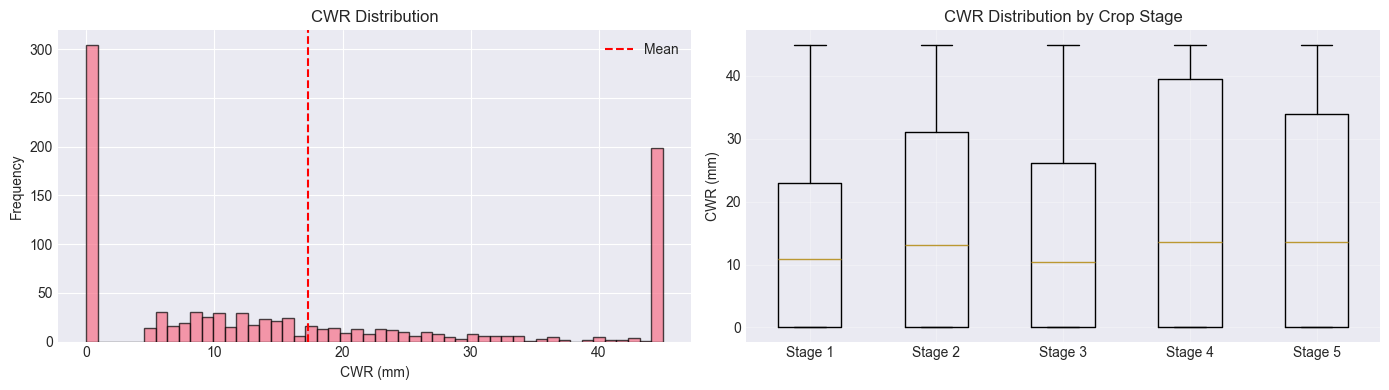

In [4]:
dataset_filename = 'Data/paddy_CWR_dataset_20260211_163930.csv'  # CHANGE THIS TO YOUR FILE

try:
    # Load dataset
    df = pd.read_csv(dataset_filename)
    
    print(f"✓ Dataset loaded successfully: {dataset_filename}")
    print(f"\nDataset shape: {df.shape}")
    print(f"Features: {df.shape[1] - 1}")
    print(f"Samples: {df.shape[0]}")
    
    # Display first few rows
    print("\nFirst 5 samples:")
    display(df.head())
    
    # Basic statistics
    print("\nDataset Statistics:")
    display(df.describe())
    
    # Check for missing values
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("\n✓ No missing values detected")
    else:
        print(f"\nMissing values found:\n{missing[missing > 0]}")
    
    # Check CWR distribution
    print("\nCWR Distribution:")
    print(f"  Min:    {df['CWR_mm'].min():.2f} mm")
    print(f"  Max:    {df['CWR_mm'].max():.2f} mm")
    print(f"  Mean:   {df['CWR_mm'].mean():.2f} mm")
    print(f"  Median: {df['CWR_mm'].median():.2f} mm")
    print(f"  Std:    {df['CWR_mm'].std():.2f} mm")
    
    # Visualize CWR distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].hist(df['CWR_mm'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('CWR (mm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('CWR Distribution')
    axes[0].axvline(df['CWR_mm'].mean(), color='red', linestyle='--', label='Mean')
    axes[0].legend()
    
    axes[1].boxplot([df[df['Crop_Stage'] == i]['CWR_mm'].values for i in range(1, 6)],
                    labels=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5'])
    axes[1].set_ylabel('CWR (mm)')
    axes[1].set_title('CWR Distribution by Crop Stage')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./Visualisation/dataset_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except FileNotFoundError:
    print(f"ERROR: File '{dataset_filename}' not found!")
    print("Please ensure your dataset file is in the same directory as this notebook.")
    print("Or update the 'dataset_filename' variable with the correct path.")


# Prepare Data for Training

In [6]:
# Separate features (X) and target (y)
feature_columns = ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 
                   'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']
target_column = 'CWR_mm'

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature Matrix (X):")
print(f"  Shape: {X.shape}")
print(f"  Features: {list(X.columns)}")

print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape}")
print(f"  Name: {target_column}")

# Split into Train (70%), Validation (15%), Test (15%)
# Use stratified split by crop stage to ensure balanced distribution
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42,
    stratify=df['Crop_Stage']  # Ensure all stages in test set
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=42,
    stratify=X_temp['Crop_Stage']
)

print("\n" + "=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"Training set:    {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set:  {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:        {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:           {len(X):4d} samples")

# Verify stage distribution
print("\nCrop Stage Distribution:")
print(f"{'Stage':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for stage in range(1, 6):
    train_count = (X_train['Crop_Stage'] == stage).sum()
    val_count = (X_val['Crop_Stage'] == stage).sum()
    test_count = (X_test['Crop_Stage'] == stage).sum()
    print(f"Stage {stage}   {train_count:>8} {val_count:>8} {test_count:>8}")

print("\nData preparation complete!")

Feature Matrix (X):
  Shape: (1000, 6)
  Features: ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']

Target Variable (y):
  Shape: (1000,)
  Name: CWR_mm

DATA SPLIT SUMMARY
Training set:     700 samples (70.0%)
Validation set:   150 samples (15.0%)
Test set:         150 samples (15.0%)
Total:           1000 samples

Crop Stage Distribution:
Stage         Train      Val     Test
--------------------------------------
Stage 1        140       30       30
Stage 2        140       30       30
Stage 3        140       30       30
Stage 4        140       30       30
Stage 5        140       30       30

Data preparation complete!


# Method 1 - Ensemble Stacking

METHOD 1: ENSEMBLE STACKING

Combining multiple diverse base models with a meta-learner
to achieve superior prediction accuracy.

STEP 1: Creating Base Models
----------------------------------------------------------------------
Created 4 diverse base models:
  • random_forest: RandomForestRegressor
  • gradient_boosting: GradientBoostingRegressor
  • ridge: Ridge
  • svr: SVR

STEP 2: Training Individual Base Models
----------------------------------------------------------------------

Training random_forest... MAE: 1.896 mm | RMSE: 3.171 mm | R²: 0.9644

Training gradient_boosting... MAE: 1.880 mm | RMSE: 3.494 mm | R²: 0.9568

Training ridge... MAE: 7.418 mm | RMSE: 9.606 mm | R²: 0.6734

Training svr... MAE: 7.637 mm | RMSE: 10.431 mm | R²: 0.6150

STEP 3: Building Stacking Ensemble
----------------------------------------------------------------------
Stacking Configuration:
  Base Models: 4
  Meta-Learner: Ridge
  CV Folds: 5

Training Stacking Ensemble...
(This may take 2-3 mi

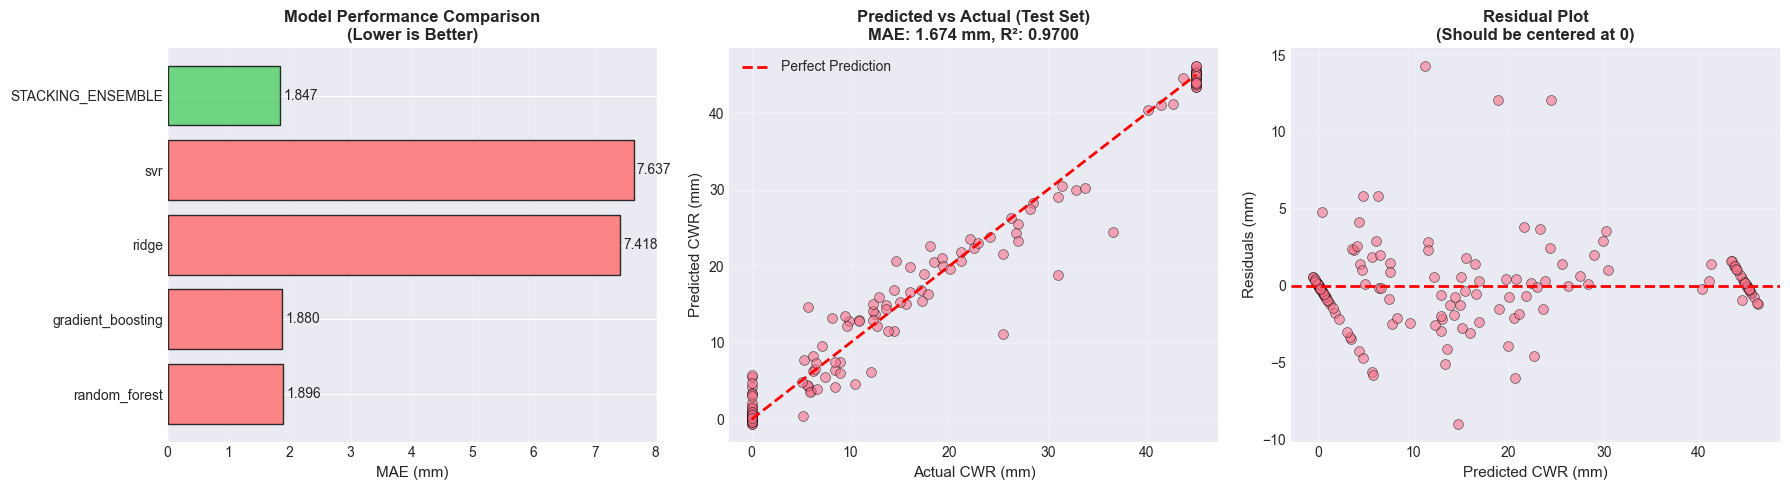


Stacking Ensemble analysis complete!
Results saved to: ./Visualisation/stacking_ensemble_results.png
Model saved to: ./Models/cwr_stacking_model.pkl


In [8]:
print("=" * 70)
print("METHOD 1: ENSEMBLE STACKING")
print("=" * 70)
print("\nCombining multiple diverse base models with a meta-learner")
print("to achieve superior prediction accuracy.\n")

# ============================================================================
# STEP 1: Define Base Models (Diverse Algorithms)
# ============================================================================

print("STEP 1: Creating Base Models")
print("-" * 70)

base_models = [
    ('random_forest', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
    
    ('gradient_boosting', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )),
    
    ('ridge', Ridge(
        alpha=1.0,
        random_state=42
    )),
    
    ('svr', SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1,
        gamma='scale'
    ))
]

print(f"Created {len(base_models)} diverse base models:")
for name, model in base_models:
    print(f"  • {name}: {type(model).__name__}")

# ============================================================================
# STEP 2: Train Individual Base Models (for comparison)
# ============================================================================

print("\nSTEP 2: Training Individual Base Models")
print("-" * 70)

base_model_scores = {}

for name, model in base_models:
    print(f"\nTraining {name}...", end=" ")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    
    base_model_scores[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    print(f"MAE: {mae:.3f} mm | RMSE: {rmse:.3f} mm | R²: {r2:.4f}")

# ============================================================================
# STEP 3: Create and Train Stacking Ensemble
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: Building Stacking Ensemble")
print("-" * 70)

# Meta-learner (learns to optimally combine base model predictions)
meta_model = Ridge(alpha=0.5, random_state=42)

# Create stacking regressor
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # Use 5-fold CV to generate meta-features
    n_jobs=-1,
    verbose=0
)

print("Stacking Configuration:")
print(f"  Base Models: {len(base_models)}")
print(f"  Meta-Learner: {type(meta_model).__name__}")
print(f"  CV Folds: 5")

print("\nTraining Stacking Ensemble...")
print("(This may take 2-3 minutes...)")

import time
start_time = time.time()

stacking_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"Training complete in {training_time:.1f} seconds")

# ============================================================================
# STEP 4: Evaluate Stacking Ensemble
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: Evaluation Results")
print("=" * 70)

# Predictions
y_train_pred_stack = stacking_model.predict(X_train)
y_val_pred_stack = stacking_model.predict(X_val)
y_test_pred_stack = stacking_model.predict(X_test)

# Calculate metrics
def evaluate_predictions(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{dataset_name} Set:")
    print(f"  MAE:  {mae:.3f} mm")
    print(f"  RMSE: {rmse:.3f} mm")
    print(f"  R²:   {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

train_metrics = evaluate_predictions(y_train, y_train_pred_stack, "Training")
val_metrics = evaluate_predictions(y_val, y_val_pred_stack, "Validation")
test_metrics = evaluate_predictions(y_test, y_test_pred_stack, "Test")

# ============================================================================
# STEP 5: Compare Stacking vs Individual Models
# ============================================================================

print("\n" + "=" * 70)
print("COMPARISON: Stacking vs Individual Base Models")
print("=" * 70)

# Add stacking results
base_model_scores['STACKING_ENSEMBLE'] = val_metrics

# Create comparison dataframe
comparison_df = pd.DataFrame(base_model_scores).T
comparison_df = comparison_df.sort_values('MAE')

print("\nValidation Set Performance (sorted by MAE):")
print(comparison_df.to_string())

# Calculate improvement
best_base_mae = comparison_df.iloc[1]['MAE']  # Second best (first is stacking)
stacking_mae = comparison_df.iloc[0]['MAE']
improvement = ((best_base_mae - stacking_mae) / best_base_mae) * 100

print(f"\nStacking Ensemble Improvement: {improvement:.2f}% better than best base model")

# ============================================================================
# STEP 6: Visualize Results
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Model Comparison
ax1 = axes[0]
models_list = list(base_model_scores.keys())
mae_values = [base_model_scores[m]['MAE'] for m in models_list]
colors = ['#ff6b6b' if m != 'STACKING_ENSEMBLE' else '#51cf66' for m in models_list]

bars = ax1.barh(models_list, mae_values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_xlabel('MAE (mm)', fontsize=11)
ax1.set_title('Model Performance Comparison\n(Lower is Better)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, mae_values)):
    ax1.text(val + 0.05, i, f'{val:.3f}', va='center', fontsize=10)

# Plot 2: Predicted vs Actual (Test Set)
ax2 = axes[1]
ax2.scatter(y_test, y_test_pred_stack, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual CWR (mm)', fontsize=11)
ax2.set_ylabel('Predicted CWR (mm)', fontsize=11)
ax2.set_title(f'Predicted vs Actual (Test Set)\nMAE: {test_metrics["MAE"]:.3f} mm, R²: {test_metrics["R2"]:.4f}',
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Residuals
ax3 = axes[2]
residuals = y_test - y_test_pred_stack
ax3.scatter(y_test_pred_stack, residuals, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Predicted CWR (mm)', fontsize=11)
ax3.set_ylabel('Residuals (mm)', fontsize=11)
ax3.set_title('Residual Plot\n(Should be centered at 0)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./Visualisation/stacking_ensemble_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nStacking Ensemble analysis complete!")
print(f"Results saved to: ./Visualisation/stacking_ensemble_results.png")

# Save stacking model
stacking_model_filename = './Models/cwr_stacking_model.pkl'
joblib.dump(stacking_model, stacking_model_filename)
print(f"Model saved to: {stacking_model_filename}")